In [66]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importar herramientas de Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Configuración de gráficos
%matplotlib inline
sns.set_palette("deep", desat=0.6)
sns.set(rc={'figure.figsize': (11.7, 8.27)})

# Cargar y preparar los datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/BC.csv")
df.set_index('id', inplace=True)

# Transformación de la variable objetivo
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0}).astype(int)

# Visualizar las primeras filas del DataFrame
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                 

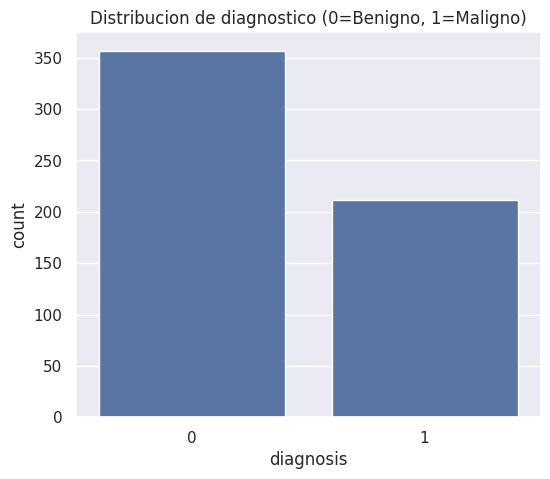

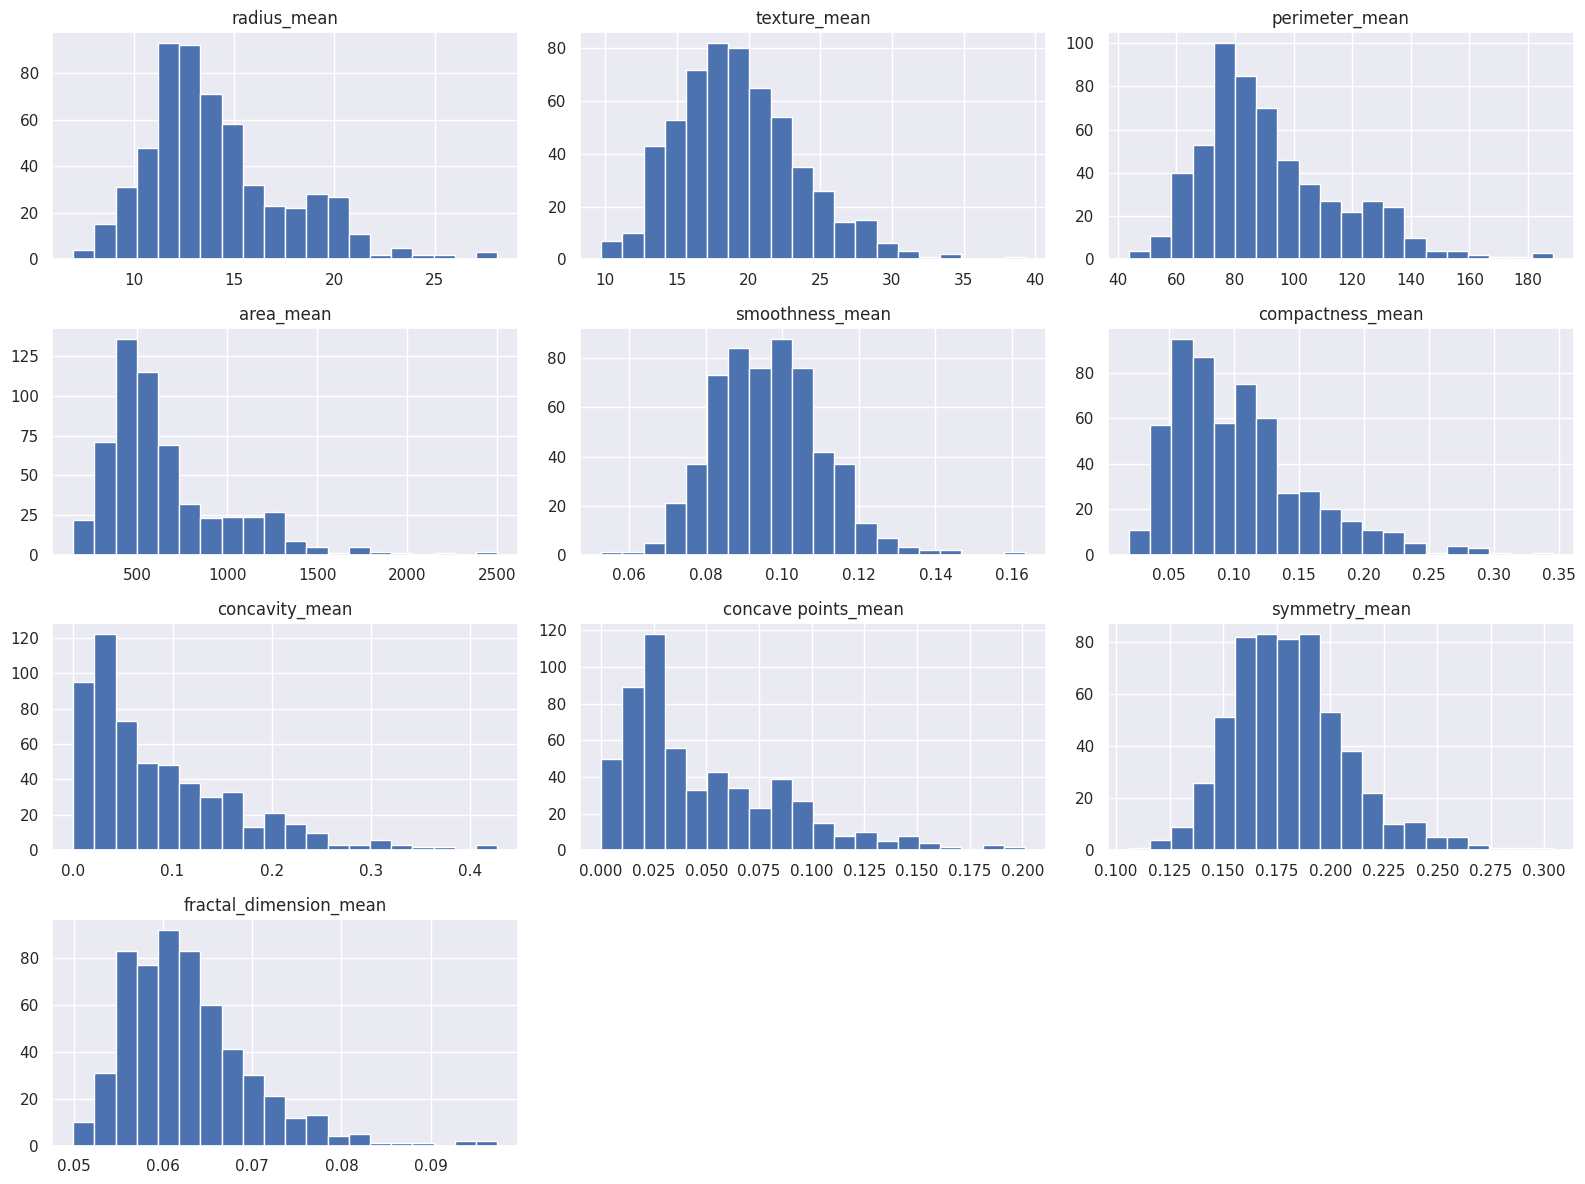

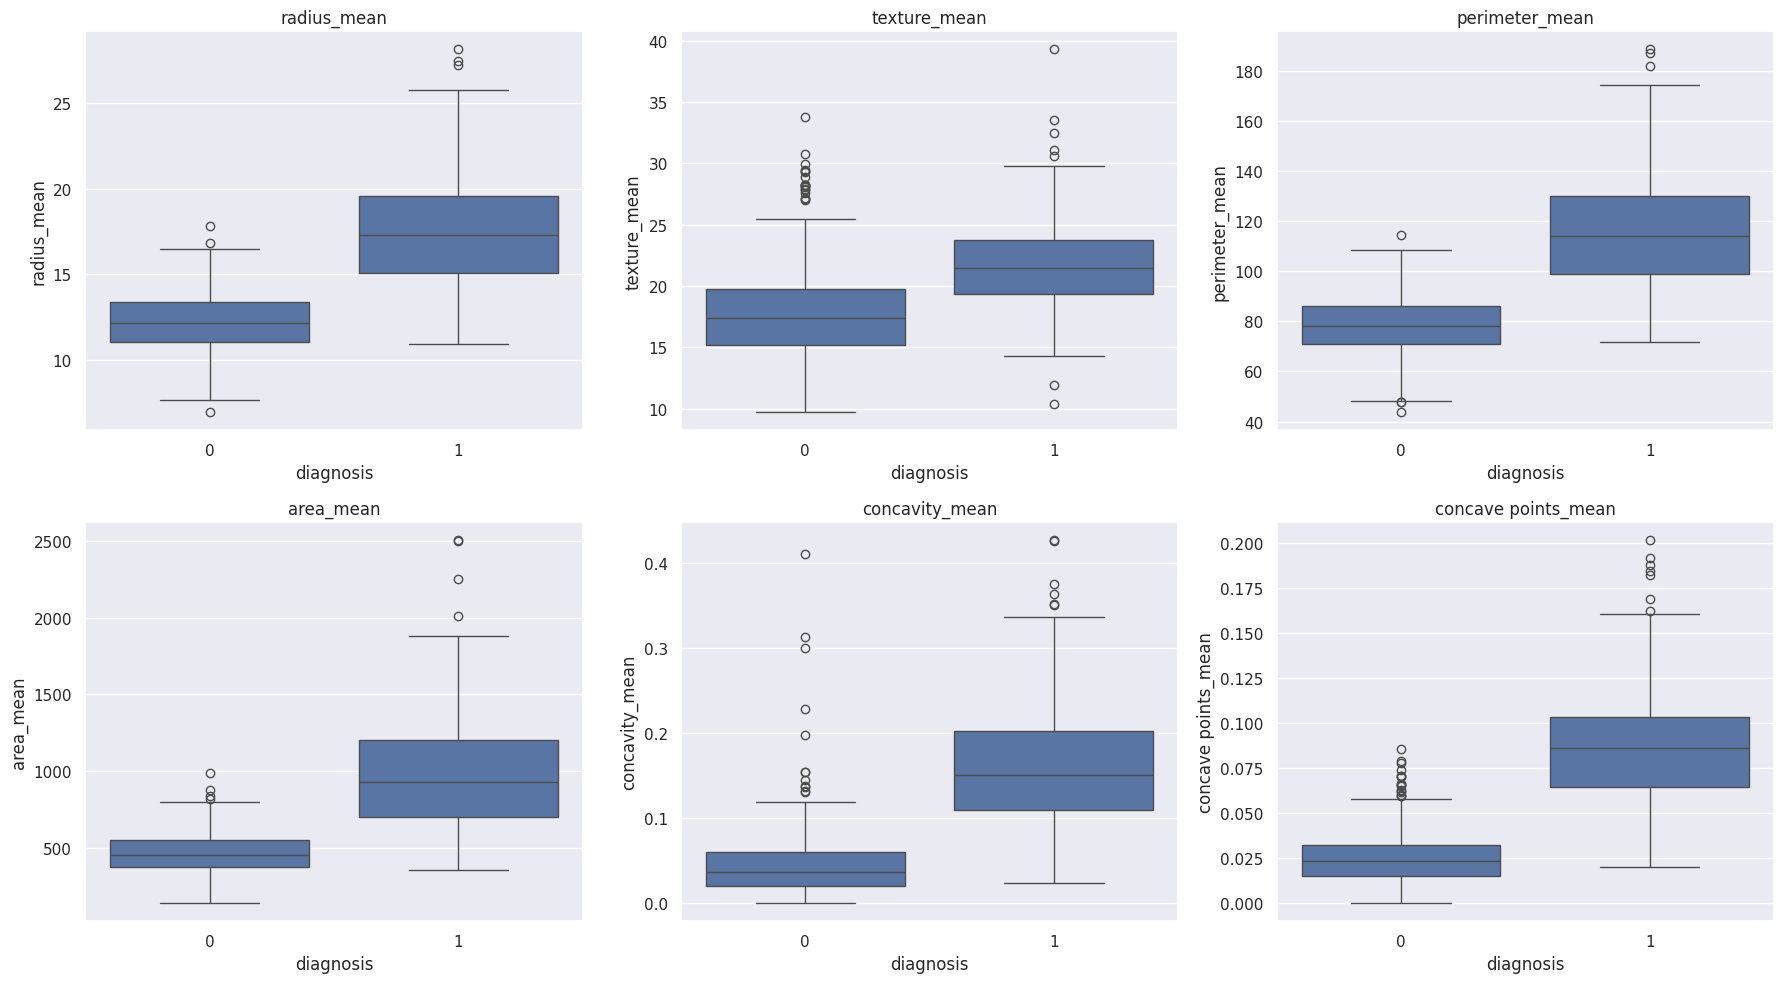

Cantidad de outliers por variable (_mean):
area_mean                 25
concavity_mean            18
compactness_mean          16
symmetry_mean             15
fractal_dimension_mean    15
radius_mean               14
perimeter_mean            13
concave points_mean       10
texture_mean               7
smoothness_mean            6
dtype: int64


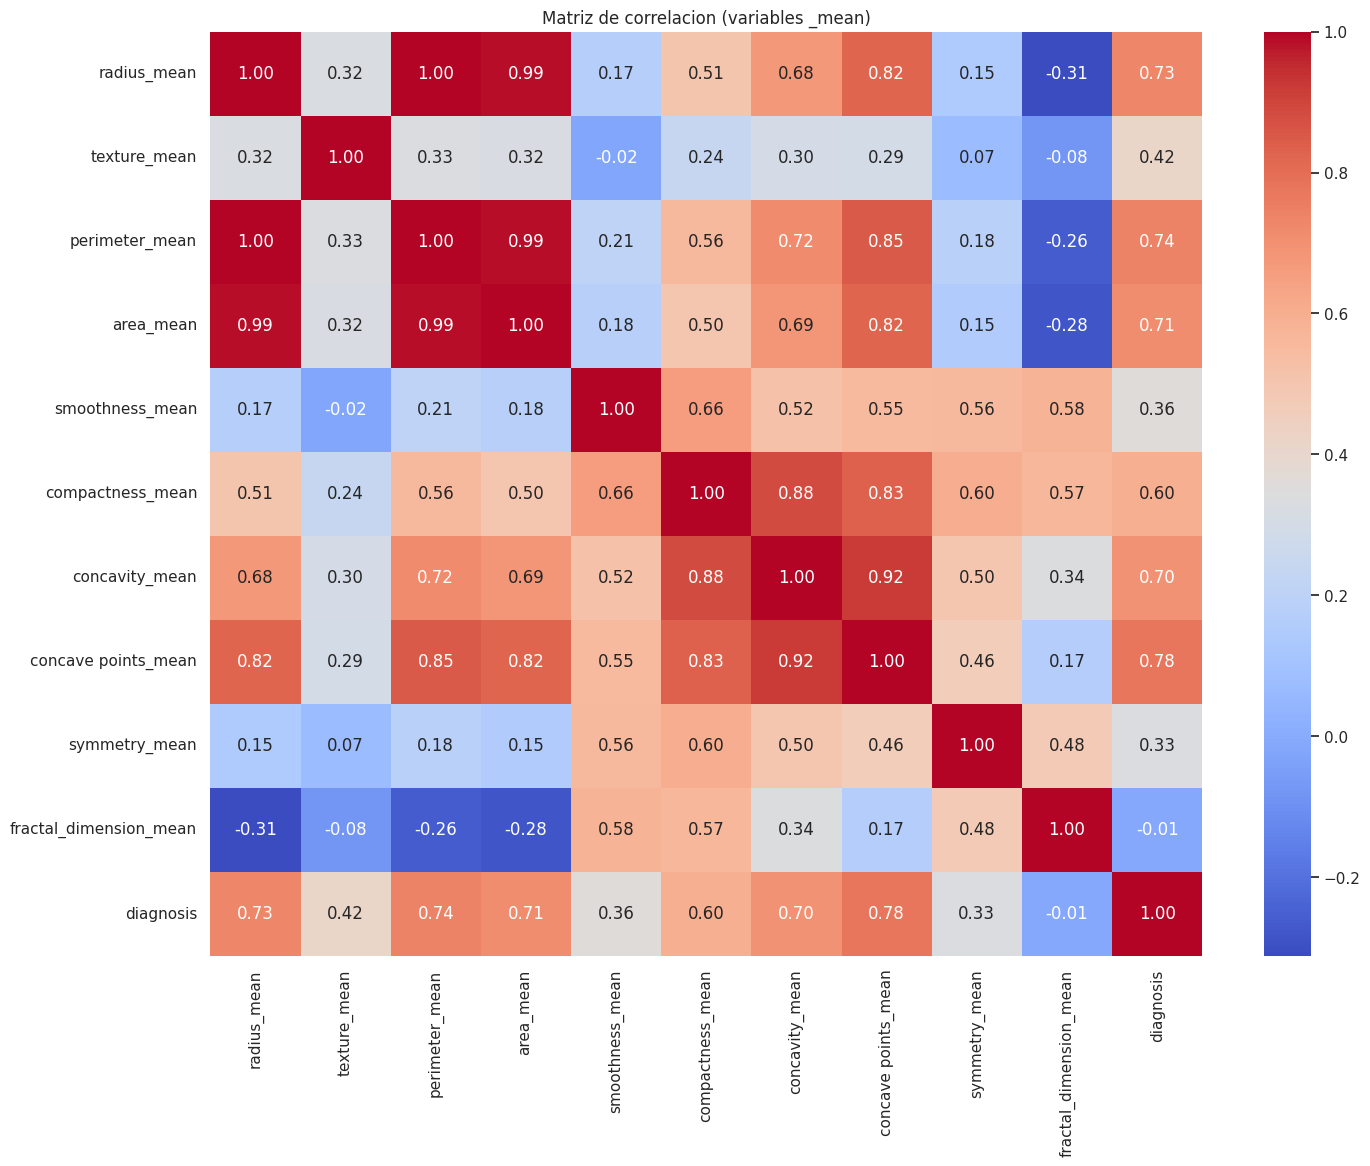

Correlacion de cada variable con diagnosis (top 10):
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: diagnosis, dtype: float64


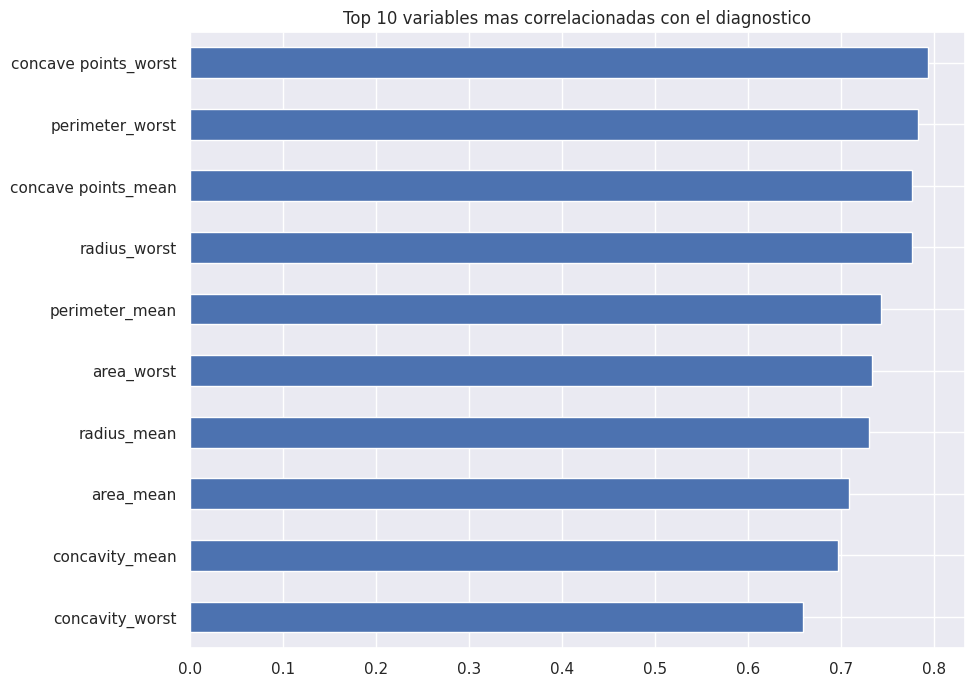

In [67]:
# ============================================================
# 1. Analisis exploratorio profundo (EDA)
# ============================================================
# Informacion general
print(df.info())
print(df.describe())
print("\nValores nulos:\n", df.isnull().sum().sum())
print("\nBalance de clases:\n", df['diagnosis'].value_counts())

plt.figure(figsize=(6, 5))
sns.countplot(x='diagnosis', data=df)
plt.title('Distribucion de diagnostico (0=Benigno, 1=Maligno)')
plt.show()

# Distribucion de variables numericas
cols_mean = [c for c in df.columns if c.endswith('_mean')]
df[cols_mean].hist(bins=20, figsize=(16, 12))
plt.tight_layout()
plt.show()

# Boxplots comparando benignos vs malignos para variables clave
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
vars_clave = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean']
for ax, var in zip(axs.flat, vars_clave):
    sns.boxplot(x='diagnosis', y=var, data=df, ax=ax)
    ax.set_title(var)
plt.tight_layout()
plt.show()

# Deteccion de outliers (metodo IQR) en variables _mean
outliers_resumen = {}
for col in cols_mean:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    outliers_resumen[col] = len(outliers)

print("Cantidad de outliers por variable (_mean):")
print(pd.Series(outliers_resumen).sort_values(ascending=False))

# Matriz de correlacion
plt.figure(figsize=(16, 12))
sns.heatmap(df[cols_mean + ['diagnosis']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlacion (variables _mean)')
plt.show()

# Correlacion de cada variable con el diagnostico
corr_diag = df.corr()['diagnosis'].drop('diagnosis').sort_values(ascending=False)
print("Correlacion de cada variable con diagnosis (top 10):")
print(corr_diag.head(10))

plt.figure(figsize=(10, 8))
corr_diag.head(10).plot(kind='barh')
plt.title('Top 10 variables mas correlacionadas con el diagnostico')
plt.gca().invert_yaxis()
plt.show()

# Discusion:
# - Las variables relacionadas con concavidad, puntos concavos, perimetro, radio y
#   area muestran las mayores diferencias entre tumores benignos y malignos, y las
#   correlaciones mas altas con la variable objetivo (diagnosis). Los boxplots
#   muestran que los tumores malignos tienden a presentar valores sistematicamente
#   mas altos en estas variables. Existen outliers en varias variables (especialmente
#   area_mean y perimeter_mean), que corresponden probablemente a tumores de mayor
#   tamaño, por lo que no se recomienda eliminarlos sin mas analisis ya que podrian
#   ser informativos para la clase maligna.

In [68]:
# ============================================================
# 2. Preprocesamiento de datos
# ============================================================
# Separar features y target
X = df.drop(columns='diagnosis')
y = df['diagnosis']

# 1) Normalizacion con StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
print(X_scaled.describe())

# 2) Estrategia adicional: eliminacion de multicolinealidad
# Se identifican pares de variables con correlacion muy alta (>0.9) y se elimina
# una de cada par, para reducir redundancia entre variables (ej. radius, perimeter y
# area suelen estar altamente correlacionadas entre si).
corr_matrix = X_scaled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

umbral = 0.9
cols_a_eliminar = [col for col in upper.columns if any(upper[col] > umbral)]
print(f"Variables eliminadas por alta multicolinealidad (>{umbral}): {len(cols_a_eliminar)}")
print(cols_a_eliminar)

X_reducido = X_scaled.drop(columns=cols_a_eliminar)
print("\nDimensiones originales:", X_scaled.shape, "-> Dimensiones reducidas:", X_reducido.shape)

# Justificacion:
# - StandardScaler es apropiado porque los modelos a usar (Regresion Logistica, SVM)
#   son sensibles a la escala de las variables.
# - La eliminacion de variables altamente correlacionadas reduce la redundancia
#   (ej. radius_mean, perimeter_mean y area_mean miden esencialmente el mismo
#   concepto de "tamaño del tumor"), lo que ayuda a evitar problemas de
#   multicolinealidad en modelos lineales y simplifica el modelo sin perder
#   demasiada informacion relevante.

        radius_mean  texture_mean  perimeter_mean     area_mean  \
count  5.690000e+02  5.690000e+02    5.690000e+02  5.690000e+02   
mean  -1.373633e-16  6.868164e-17   -1.248757e-16 -2.185325e-16   
std    1.000880e+00  1.000880e+00    1.000880e+00  1.000880e+00   
min   -2.029648e+00 -2.229249e+00   -1.984504e+00 -1.454443e+00   
25%   -6.893853e-01 -7.259631e-01   -6.919555e-01 -6.671955e-01   
50%   -2.150816e-01 -1.046362e-01   -2.359800e-01 -2.951869e-01   
75%    4.693926e-01  5.841756e-01    4.996769e-01  3.635073e-01   
max    3.971288e+00  4.651889e+00    3.976130e+00  5.250529e+00   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count     5.690000e+02      5.690000e+02    5.690000e+02         5.690000e+02   
mean     -8.366672e-16      1.873136e-16    4.995028e-17        -4.995028e-17   
std       1.000880e+00      1.000880e+00    1.000880e+00         1.000880e+00   
min      -3.112085e+00     -1.610136e+00   -1.114873e+00        -1.26182

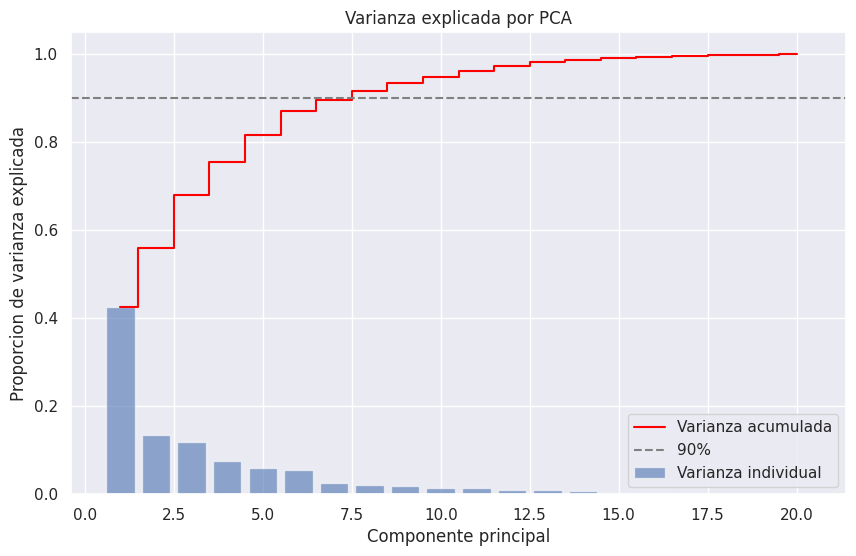

Componentes necesarios para explicar >=90% de la varianza: 8


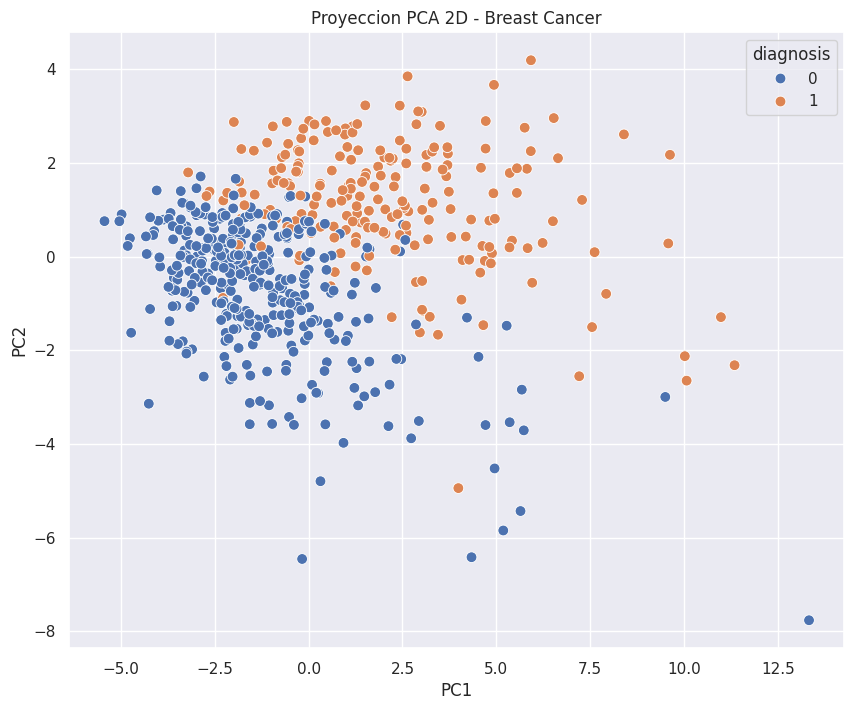

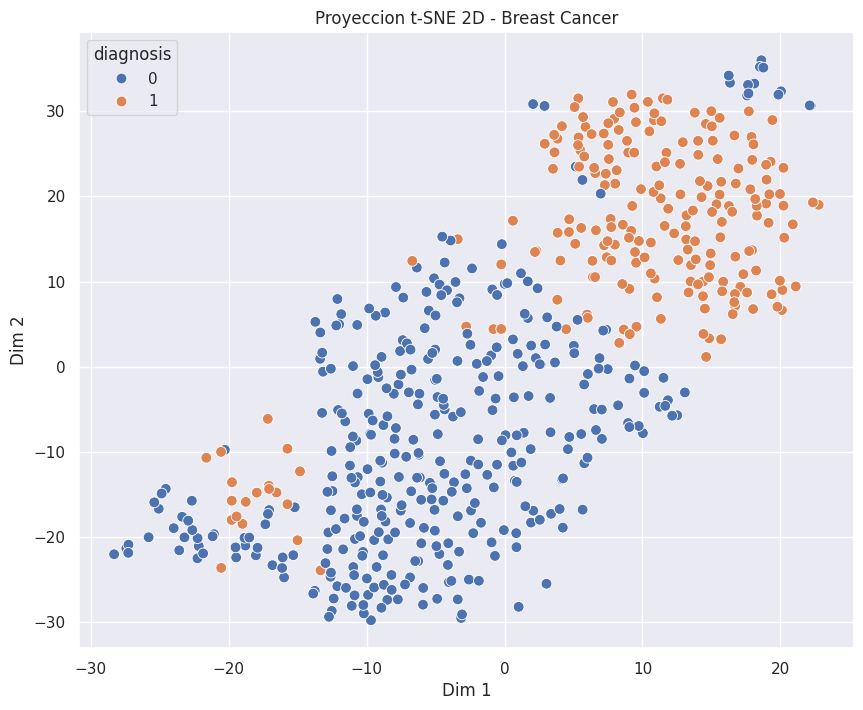

In [69]:
# ============================================================
# 3. Reduccion de dimensionalidad
# ============================================================
# PCA sobre los datos normalizados (y con multicolinealidad reducida)
pca_full = PCA()
pca_full.fit(X_reducido)

var_exp = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(var_exp)+1), var_exp, alpha=0.6, label='Varianza individual')
plt.step(range(1, len(var_acum)+1), var_acum, where='mid', color='red', label='Varianza acumulada')
plt.axhline(y=0.90, color='gray', linestyle='--', label='90%')
plt.xlabel('Componente principal')
plt.ylabel('Proporcion de varianza explicada')
plt.title('Varianza explicada por PCA')
plt.legend()
plt.show()

n_90 = np.argmax(var_acum >= 0.90) + 1
print(f"Componentes necesarios para explicar >=90% de la varianza: {n_90}")

# Proyeccion 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_reducido)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y, palette='deep', s=60)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Proyeccion PCA 2D - Breast Cancer')
plt.show()

# t-SNE 2D para comparar
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_reducido)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='deep', s=60)
plt.xlabel('Dim 1'); plt.ylabel('Dim 2')
plt.title('Proyeccion t-SNE 2D - Breast Cancer')
plt.show()

# Comparacion:
# - Con PCA, las dos primeras componentes ya explican una gran parte de la varianza
#   y se observa una separacion razonable entre benignos y malignos, aunque con
#   cierto solapamiento en la zona limite.
# - t-SNE, al ser no lineal, suele mostrar una separacion visualmente mas nitida
#   entre las dos clases, agrupando los casos malignos y benignos en regiones mas
#   compactas y separadas.
# - En ambos casos se confirma que existe una estructura subyacente que distingue
#   bien a los tumores malignos de los benignos, lo que sugiere que modelos de
#   clasificacion relativamente simples deberian obtener buen desempeño.

Train: (455, 20) Test: (114, 20)
               modelo                              mejores_parametros  \
0  LogisticRegression                                        {'C': 1}   
1                 SVM  {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}   
2        RandomForest        {'max_depth': None, 'n_estimators': 200}   

   accuracy  precision  recall  f1_score  auc_roc  
0    0.9737     1.0000  0.9286     0.963   0.9944  
1    0.9737     1.0000  0.9286     0.963   0.9871  
2    0.9474     0.9737  0.8810     0.925   0.9922  


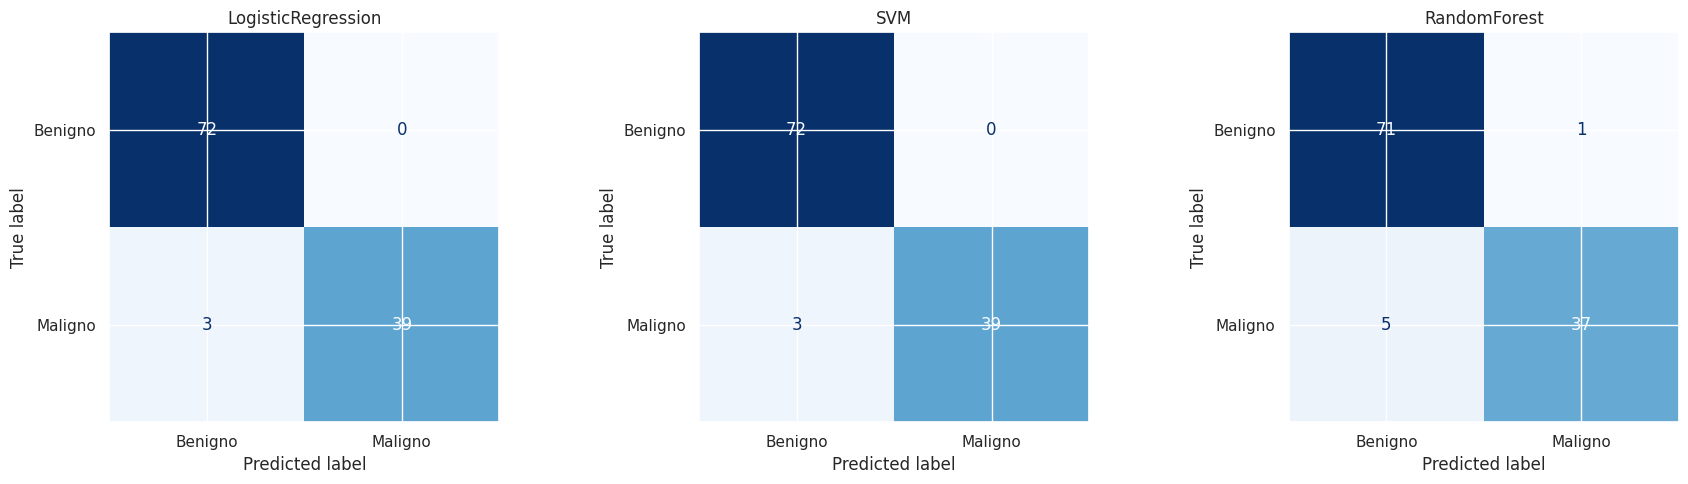

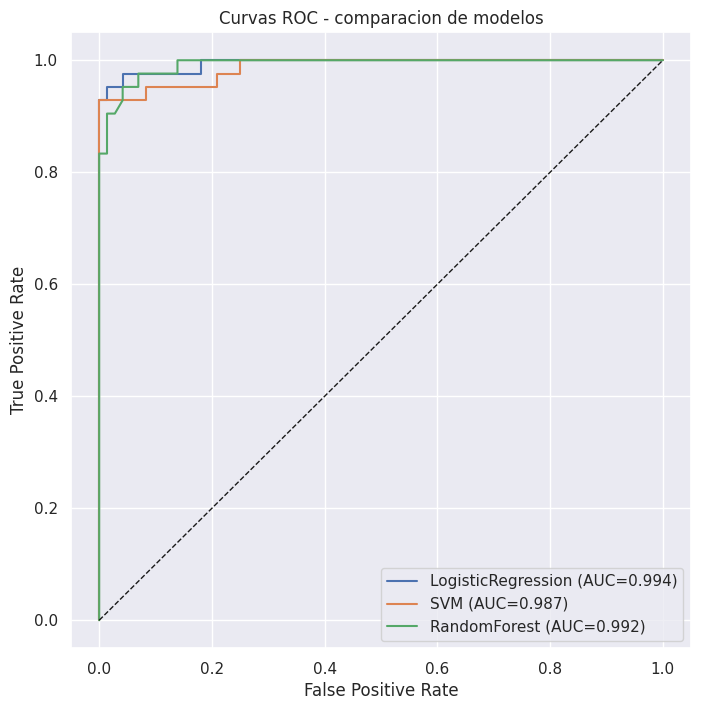


Mejor modelo segun F1-score: LogisticRegression
               modelo                              mejores_parametros  \
0  LogisticRegression                                        {'C': 1}   
1                 SVM  {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}   
2        RandomForest        {'max_depth': None, 'n_estimators': 200}   

   accuracy  precision  recall  f1_score  auc_roc  
0    0.9737     1.0000  0.9286     0.963   0.9944  
1    0.9737     1.0000  0.9286     0.963   0.9871  
2    0.9474     0.9737  0.8810     0.925   0.9922  


In [70]:
# ============================================================
# 4. Modelado y evaluacion
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Split de entrenamiento y test (usando datos preprocesados, sin reduccion de dimensionalidad
# para no perder informacion antes del modelado)
X_train, X_test, y_train, y_test = train_test_split(X_reducido, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, "Test:", X_test.shape)

# Definicion de modelos y grillas de hiperparametros
param_grids = {
    "LogisticRegression": {
        "modelo": LogisticRegression(max_iter=5000),
        "params": {"C": [0.01, 0.1, 1, 10, 100]}
    },
    "SVM": {
        "modelo": SVC(probability=True),
        "params": {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"], "gamma": ["scale", "auto"]}
    },
    "RandomForest": {
        "modelo": RandomForestClassifier(random_state=42),
        "params": {"n_estimators": [100, 200], "max_depth": [None, 5, 10]}
    }
}

resultados = []
modelos_entrenados = {}
predicciones = {}
probabilidades = {}

for nombre, config in param_grids.items():
    grid = GridSearchCV(config["modelo"], config["params"], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)

    mejor_modelo = grid.best_estimator_
    modelos_entrenados[nombre] = mejor_modelo

    y_pred = mejor_modelo.predict(X_test)
    y_proba = mejor_modelo.predict_proba(X_test)[:, 1]
    predicciones[nombre] = y_pred
    probabilidades[nombre] = y_proba

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)

    resultados.append({
        "modelo": nombre,
        "mejores_parametros": grid.best_params_,
        "accuracy": round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred), 4),
        "recall": round(recall_score(y_test, y_pred), 4),
        "f1_score": round(f1_score(y_test, y_pred), 4),
        "auc_roc": round(auc_score, 4)
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados)

# Matrices de confusion
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nombre, y_pred) in zip(axs, predicciones.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Maligno'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

# Curvas ROC comparadas
plt.figure(figsize=(8, 8))
for nombre, y_proba in probabilidades.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC={auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC - comparacion de modelos')
plt.legend()
plt.show()

mejor_modelo_nombre = df_resultados.sort_values('f1_score', ascending=False).iloc[0]['modelo']
print(f"\nMejor modelo segun F1-score: {mejor_modelo_nombre}")
print(df_resultados.sort_values('f1_score', ascending=False))

In [71]:
# ============================================================
# 5. Conclusiones y reflexiones
# ============================================================
print("Modelo elegido:", mejor_modelo_nombre)
print(df_resultados.sort_values('f1_score', ascending=False))

# - El modelo con mejor compromiso entre precision y generalizacion fue el indicado
#   arriba, considerando F1-score y AUC-ROC en conjunto (no solo accuracy, ya que en
#   diagnostico medico el costo de un falso negativo -maligno clasificado como
#   benigno- es mucho mayor que el de un falso positivo).
# - El preprocesamiento (normalizacion + eliminacion de multicolinealidad) permitio
#   que modelos sensibles a la escala (Logistic Regression, SVM) funcionaran
#   correctamente y ademas simplifico el conjunto de variables sin perder
#   informacion relevante.
# - PCA y t-SNE confirmaron que existe una estructura clara que separa tumores
#   benignos de malignos, lo cual es coherente con el buen desempeño alcanzado
#   por los modelos supervisados.
# - Posibles mejoras: probar tecnicas de balanceo de clases (SMOTE) si el dataset
#   estuviera mas desbalanceado, usar modelos adicionales (XGBoost, redes
#   neuronales), aplicar validacion cruzada anidada para una estimacion mas robusta
#   del desempeño, y en un escenario real, priorizar recall (sensibilidad) para
#   minimizar el riesgo de no detectar un tumor maligno, incluso a costa de mas
#   falsos positivos que luego serian revisados por un especialista.

Modelo elegido: LogisticRegression
               modelo                              mejores_parametros  \
0  LogisticRegression                                        {'C': 1}   
1                 SVM  {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}   
2        RandomForest        {'max_depth': None, 'n_estimators': 200}   

   accuracy  precision  recall  f1_score  auc_roc  
0    0.9737     1.0000  0.9286     0.963   0.9944  
1    0.9737     1.0000  0.9286     0.963   0.9871  
2    0.9474     0.9737  0.8810     0.925   0.9922  
